<a href="https://colab.research.google.com/github/fauziahroikhanawar/Analisis_Ketahanan_Pipeline_Instance_Segmentation_Klasik/blob/main/notebook/instance_segmentation_tumbler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini Project: Pengolahan Citra Digital
## Analisis Ketahanan Pipeline Instance Segmentation Klasik pada Citra Silindris (Tumbler)

**Tujuan:** Menguji pipeline segmentasi instans klasik (tanpa deep learning) untuk mendeteksi tumbler:
- **Image 1**: 2 tumbler (biru + hitam) dengan background sangat noisy (kain bunga, lemari, barang)
- **Image 2**: 1 tumbler (biru) dengan background keramik yang lebih bersih

## Tahap 0: Persiapan Data & Library

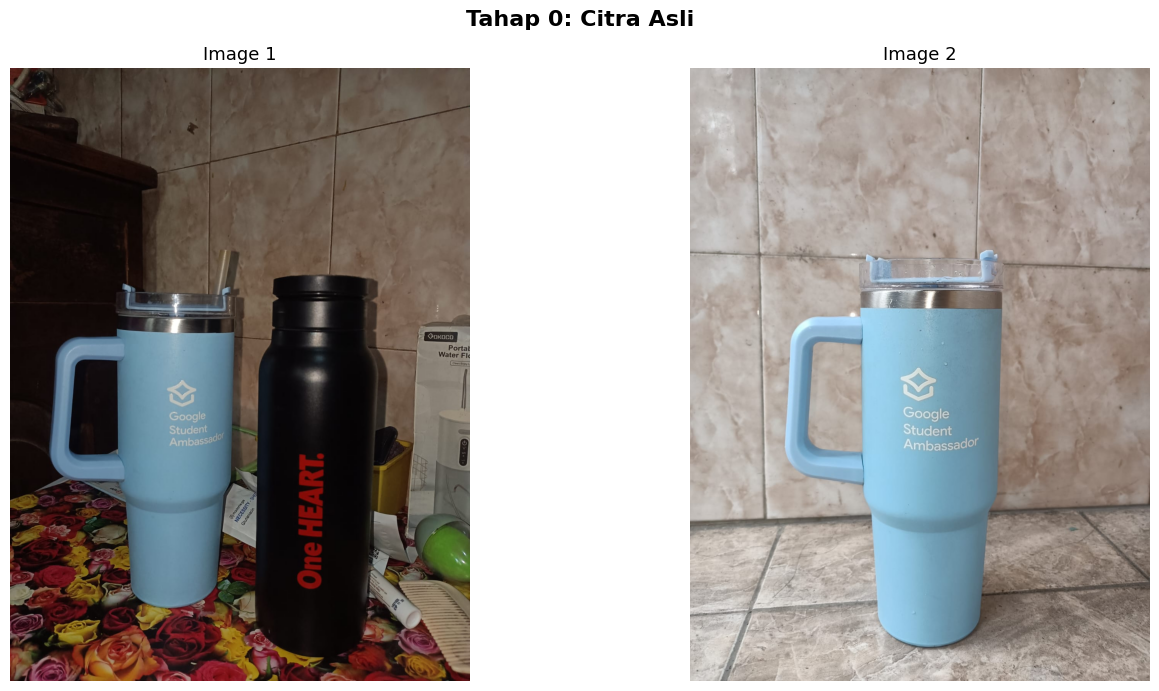

Image 1: (1600, 1200, 3) | Image 2: (1600, 1200, 3)


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def tampilkan_komparasi(img1, img2, judul1='Image 1', judul2='Image 2', title='', cmap1=None, cmap2=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
    ax1.imshow(img1, cmap=cmap1); ax1.set_title(judul1, fontsize=13); ax1.axis('off')
    ax2.imshow(img2, cmap=cmap2); ax2.set_title(judul2, fontsize=13); ax2.axis('off')
    if title: fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout(); plt.show()

img1_bgr = cv2.imread('image1.jpeg')
img2_bgr = cv2.imread('image2.jpeg')
assert img1_bgr is not None, "image1.jpeg tidak ditemukan!"
assert img2_bgr is not None, "image2.jpeg tidak ditemukan!"
img1_rgb = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2RGB)
tampilkan_komparasi(img1_rgb, img2_rgb, title='Tahap 0: Citra Asli')
print(f"Image 1: {img1_bgr.shape} | Image 2: {img2_bgr.shape}")

## Tahap 1: Konversi Grayscale & Analisis HSV
Grayscale mereduksi 3 channel menjadi 1. Namun tumbler hitam memiliki intensitas mirip background gelap, sehingga analisis **HSV** diperlukan. Channel **Hue** merepresentasikan warna murni terlepas kecerahan.

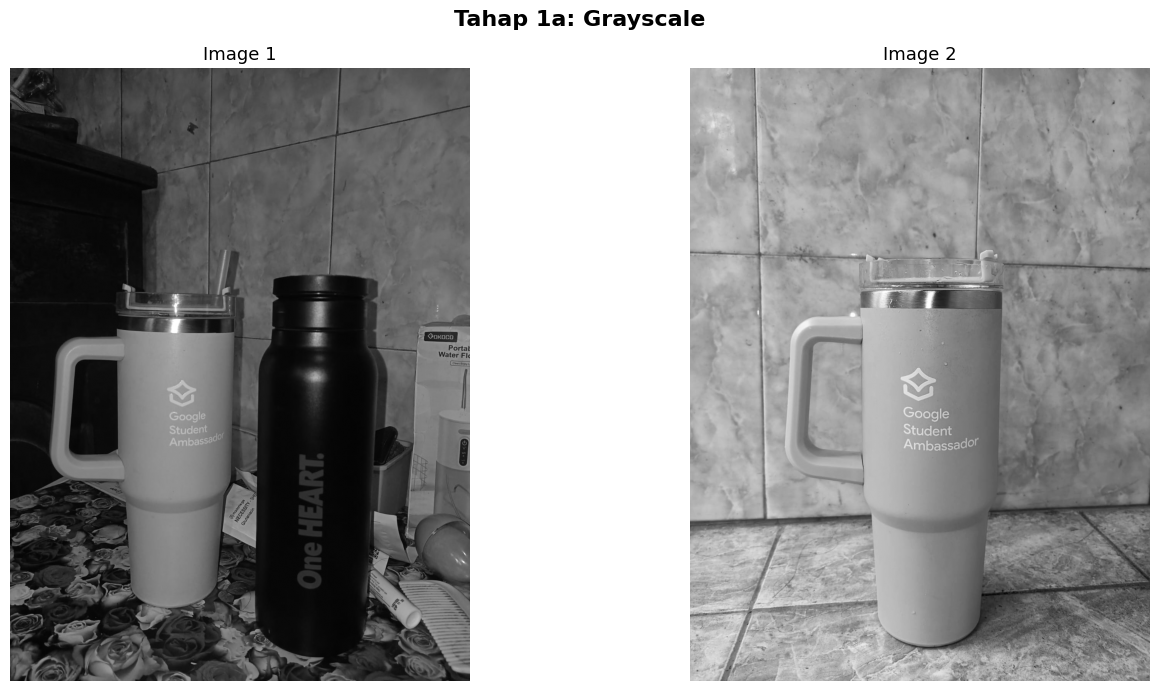

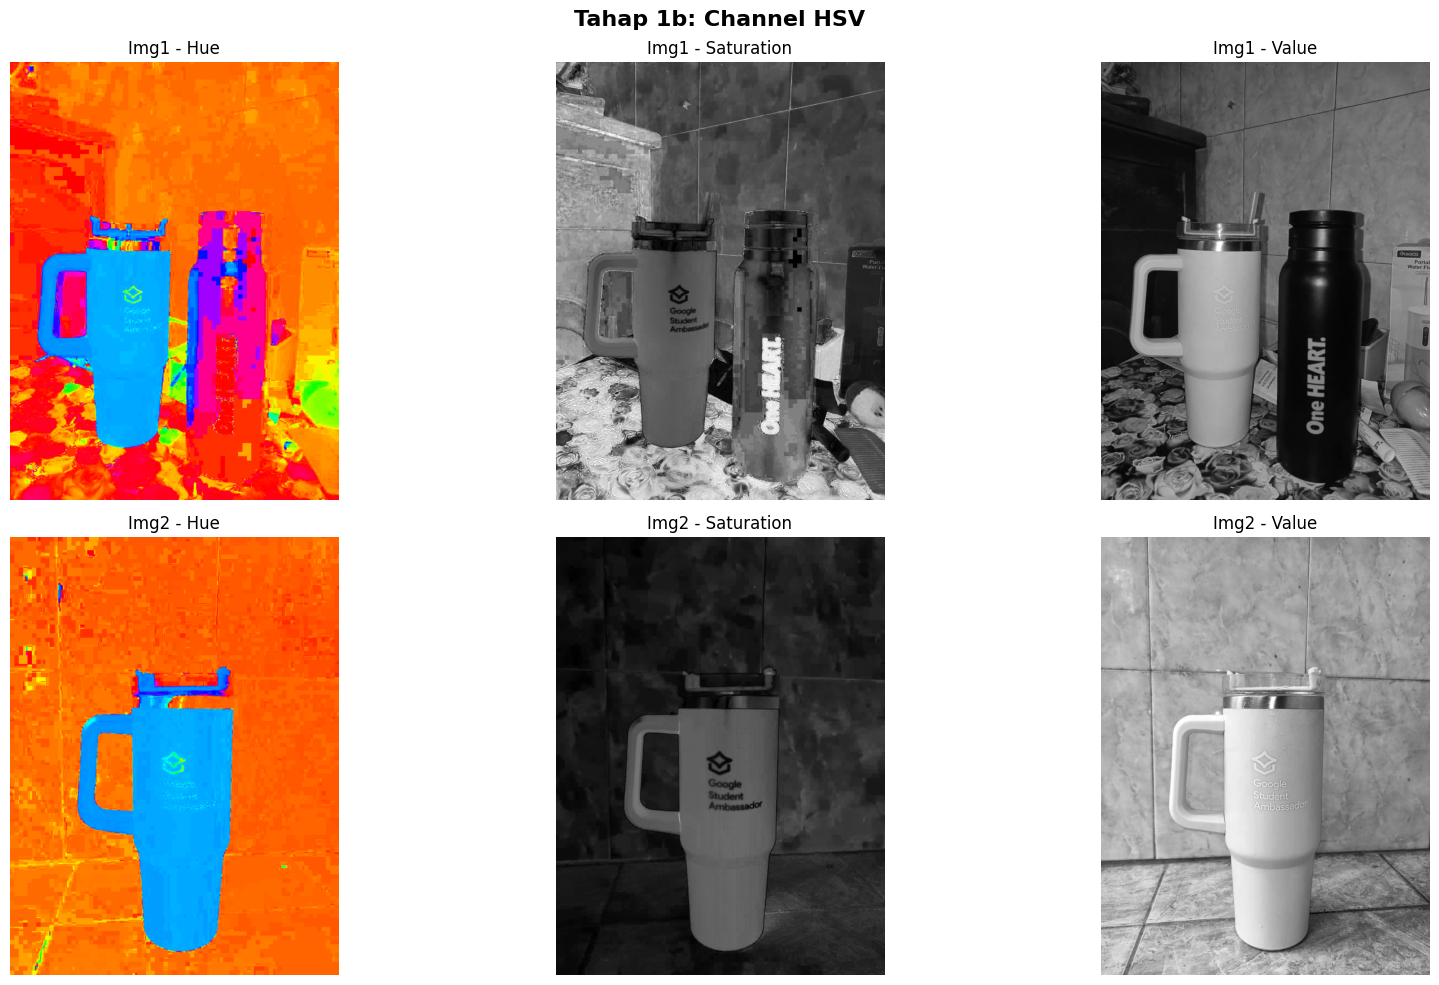

In [ ]:
img1_gray = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2GRAY)
img2_gray = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2GRAY)
tampilkan_komparasi(img1_gray, img2_gray, cmap1='gray', cmap2='gray', title='Tahap 1a: Grayscale')

img1_hsv = cv2.cvtColor(img1_bgr, cv2.COLOR_BGR2HSV)
img2_hsv = cv2.cvtColor(img2_bgr, cv2.COLOR_BGR2HSV)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i, (name, cm) in enumerate([('Hue','hsv'),('Saturation','gray'),('Value','gray')]):
    axes[0,i].imshow(img1_hsv[:,:,i], cmap=cm); axes[0,i].set_title(f'Img1 - {name}'); axes[0,i].axis('off')
    axes[1,i].imshow(img2_hsv[:,:,i], cmap=cm); axes[1,i].set_title(f'Img2 - {name}'); axes[1,i].axis('off')
fig.suptitle('Tahap 1b: Channel HSV', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

## Analisis Hasil & Insight: Tahap 1 (Konversi Grayscale & Analisis HSV)

### 1a. Grayscale

Konversi grayscale mereduksi citra dari 3 channel (BGR) menjadi 1 channel intensitas menggunakan formula luminance-weighted: `Y = 0.299R + 0.587G + 0.114B`.

**Image 1 (Indoor — 2 Tumbler):**
- Tumbler **biru** tampil sebagai area **abu-abu terang** (intensitas ≈170–200) — cukup kontras terhadap sebagian background.
- Tumbler **hitam** tampil **sangat gelap** (intensitas ≈10–50), hampir menyatu dengan bayangan dan lemari kayu di belakangnya. Ini menjadi bukti bahwa **grayscale saja tidak cukup** untuk memisahkan objek achromatic gelap dari background gelap.
- Background sangat noisy: kain bermotif bunga (high-frequency texture), lemari kayu, kotak kardus — semuanya menghasilkan variasi intensitas yang tinggi.

**Image 2 (Indoor — 1 Tumbler):**
- Tumbler biru tampil sebagai area **abu-abu terang homogen**, kontras cukup baik terhadap dinding keramik yang berwarna abu-abu medium.
- Background relatif bersih dengan tekstur keramik yang halus — segmentasi berbasis intensitas lebih memungkinkan di sini.

**Kesimpulan Grayscale:** Informasi warna hilang sepenuhnya. Tumbler biru dan tumbler hitam yang secara visual sangat berbeda (biru vs hitam) kini hanya dibedakan oleh tingkat kecerahan — dan pada Image 1, background gelap membuat tumbler hitam **nyaris tidak terlihat**.

---

### 1b. Channel HSV

Konversi ke HSV memisahkan informasi warna menjadi 3 komponen independen:
- **Hue (H):** Warna murni (0–180 di OpenCV), tidak terpengaruh kecerahan
- **Saturation (S):** Kepekatan warna (0=abu-abu, 255=warna jenuh)
- **Value (V):** Kecerahan (0=hitam, 255=putih)

#### Channel Hue

| Aspek | Image 1 | Image 2 |
|-------|---------|---------|
| Tumbler biru | Tampil **cyan/biru** (H≈100–120), sangat kontras terhadap background oranye | Tampil **cyan/biru** yang jelas, mudah di-threshold |
| Tumbler hitam | Tampil **magenta/ungu** — **noise Hue**! Piksel sangat gelap (V<30) menghasilkan nilai Hue yang tidak stabil dan tidak bermakna | — |
| Background | Dominan **oranye/merah** (ubin, kayu, kain bunga) | Dominan oranye seragam |

> **Temuan penting:** Hue channel sangat efektif untuk mendeteksi tumbler **biru** karena hue-nya (≈100–120) unik dan berbeda jauh dari background. Namun, untuk tumbler **hitam**, Hue **tidak reliable** — objek achromatic gelap menghasilkan noise Hue yang acak.

#### Channel Saturation

| Aspek | Image 1 | Image 2 |
|-------|---------|---------|
| Tumbler biru | **Saturasi sedang** (S≈40–120) — biru pastel, bukan biru murni | Saturasi sedang, konsisten |
| Tumbler hitam | **Saturasi sangat rendah** (S<30) — achromatic, seperti yang diharapkan dari objek berwarna hitam | — |
| Background | Kain bunga memiliki saturasi **tinggi** (merah, kuning); ubin dan kayu saturasi **rendah** | Keramik saturasi rendah |

> **Temuan:** Saturasi bisa digunakan sebagai **filter negatif** — mengeliminasi area berwarna kuat (kain bunga) dari kandidat tumbler hitam. Namun background lemari kayu juga ber-saturasi rendah, sehingga saturasi saja tidak cukup membedakan tumbler hitam dari background.

#### Channel Value

| Aspek | Image 1 | Image 2 |
|-------|---------|---------|
| Tumbler biru | **Terang** (V≈150–200) — mudah dibedakan | Terang dan homogen |
| Tumbler hitam | **Sangat gelap** (V≈10–50) — tumpang-tindih dengan bayangan dan area gelap lemari kayu | — |
| Background | Variasi besar: kain bunga cerah, bayangan gelap, ubin medium | Keramik medium-terang |

> **Temuan:** Value channel mempertegas masalah utama — tumbler hitam memiliki V yang **terlalu mirip** dengan bayangan dan furnitur gelap untuk bisa diisolasi dengan thresholding sederhana.

---

### Justifikasi Keputusan Pipeline

Dari analisis 4 representasi (Grayscale, H, S, V), dapat disimpulkan:

1. **Tumbler biru** → Dapat dideteksi secara efektif melalui **Hue-based thresholding** (H=85–130), karena warna birunya unik di antara background yang dominan oranye/coklat.
2. **Tumbler hitam** → **Tidak ada single channel** yang cukup untuk mengisolasinya:
   - Grayscale/Value: tumpang-tindih dengan bayangan
   - Hue: noise (tidak bermakna untuk piksel gelap)
   - Saturation: tumpang-tindih dengan ubin/kayu
   
   → Diperlukan pendekatan lain yang lebih canggih (di tahap selanjutnya: **GrabCut** berbasis graph-cut dengan ROI anchor dari posisi tumbler biru).


---

## Tahap 2: Spatial Filtering — Bilateral Filter
**Bilateral Filter** bersifat *edge-preserving*: menghaluskan area datar namun mempertahankan tepi objek.

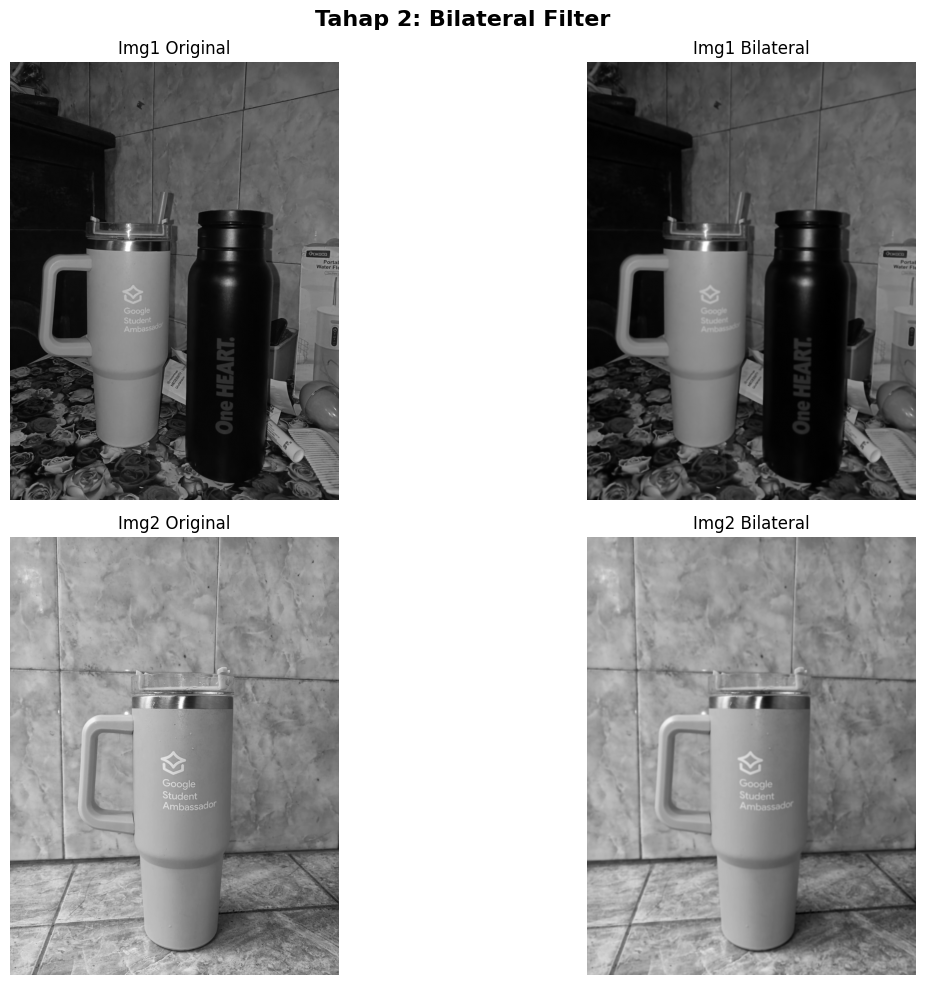

In [ ]:
img1_bilat = cv2.bilateralFilter(img1_gray, 9, 75, 75)
img2_bilat = cv2.bilateralFilter(img2_gray, 9, 75, 75)
img1_bgr_f = cv2.bilateralFilter(img1_bgr, 9, 75, 75)
img2_bgr_f = cv2.bilateralFilter(img2_bgr, 9, 75, 75)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].imshow(img1_gray, cmap='gray'); axes[0,0].set_title('Img1 Original'); axes[0,0].axis('off')
axes[0,1].imshow(img1_bilat, cmap='gray'); axes[0,1].set_title('Img1 Bilateral'); axes[0,1].axis('off')
axes[1,0].imshow(img2_gray, cmap='gray'); axes[1,0].set_title('Img2 Original'); axes[1,0].axis('off')
axes[1,1].imshow(img2_bilat, cmap='gray'); axes[1,1].set_title('Img2 Bilateral'); axes[1,1].axis('off')
fig.suptitle('Tahap 2: Bilateral Filter', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.show()

## Analisis Hasil & Insight Tahap 2: Spatial Filtering — Bilateral Filter

Parameter yang digunakan: `cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)`

### Hasil Observasi

**Image 1:**
- Area datar seperti body tumbler biru dan permukaan tumbler hitam menjadi **lebih halus** — noise kecil dan grain kamera berkurang.
- **Tepi objek tetap tajam** — batas antara tumbler biru dan background, serta outline tumbler hitam terhadap ubin, masih terjaga dengan baik.
- Tekstur kain bunga di bagian bawah sedikit tersmoothing, namun pola utamanya masih terlihat.

**Image 2:**
- Permukaan tumbler menjadi lebih homogen — gradasi pencahayaan pada body terlihat lebih mulus.
- Tepi tumbler terhadap dinding keramik tetap tajam dan jelas.
- Tekstur nat keramik di background masih terjaga.

### Mengapa Bilateral Filter?

Bilateral filter dipilih dibanding Gaussian blur biasa karena sifatnya yang **edge-preserving** — ia memperhitungkan kedekatan spasial **dan** kesamaan intensitas piksel. Ini penting karena:
- Noise perlu direduksi agar tahap binarisasi (Tahap 4) tidak menghasilkan fragmen kecil palsu
- Tepi objek harus dipertahankan agar kontur tumbler tidak kabur/melebar saat segmentasi

---


## Tahap 3: CLAHE (Contrast Enhancement)
CLAHE meningkatkan kontras lokal, efektif menangani iluminasi tidak merata.

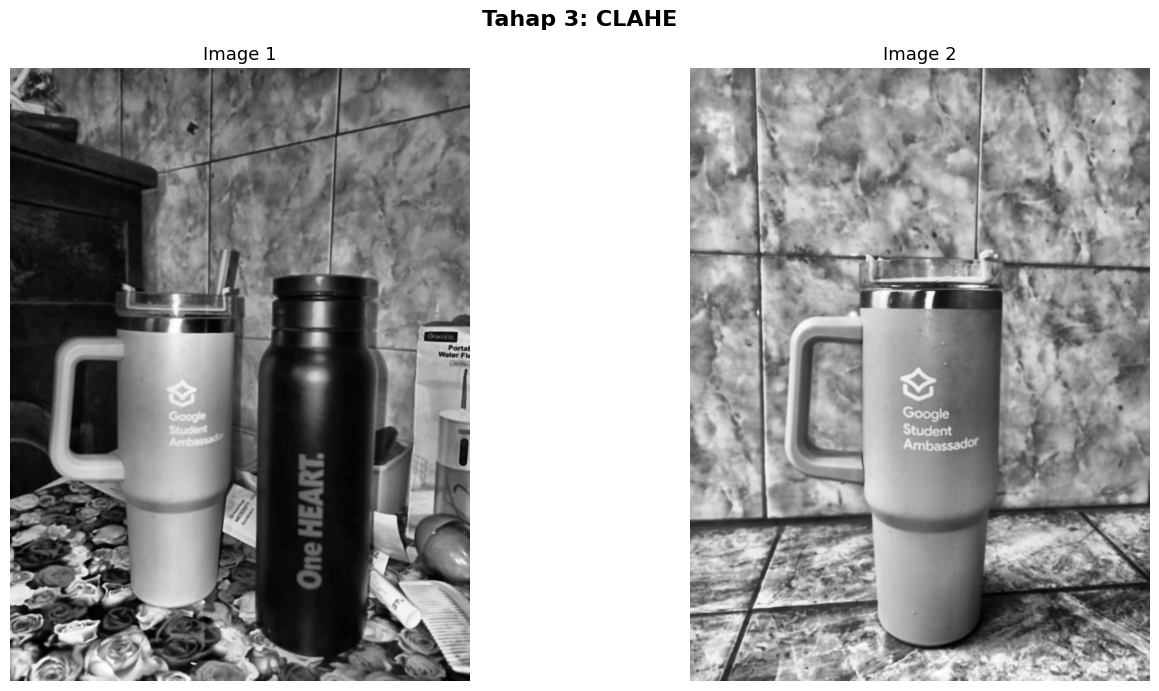

In [ ]:
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
img1_clahe = clahe.apply(img1_bilat)
img2_clahe = clahe.apply(img2_bilat)
tampilkan_komparasi(img1_clahe, img2_clahe, cmap1='gray', cmap2='gray', title='Tahap 3: CLAHE')

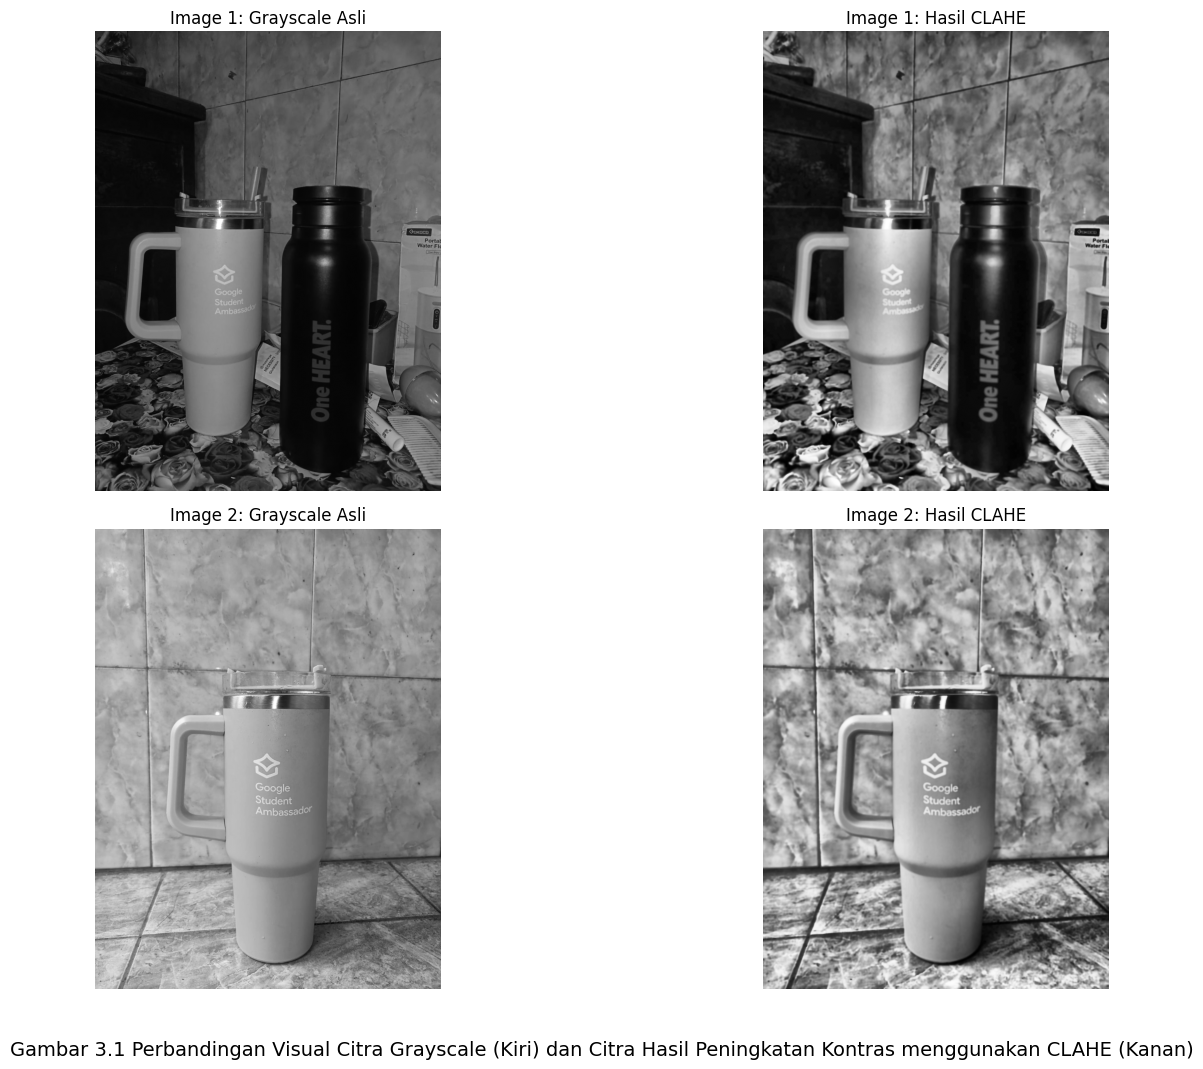

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Image 1 Comparison
axes[0,0].imshow(img1_gray, cmap='gray')
axes[0,0].set_title('Image 1: Grayscale Asli')
axes[0,0].axis('off')

axes[0,1].imshow(img1_clahe, cmap='gray')
axes[0,1].set_title('Image 1: Hasil CLAHE')
axes[0,1].axis('off')

# Image 2 Comparison
axes[1,0].imshow(img2_gray, cmap='gray')
axes[1,0].set_title('Image 2: Grayscale Asli')
axes[1,0].axis('off')

axes[1,1].imshow(img2_clahe, cmap='gray')
axes[1,1].set_title('Image 2: Hasil CLAHE')
axes[1,1].axis('off')

fig.suptitle('Gambar 3.1 Perbandingan Visual Citra Grayscale (Kiri) dan Citra Hasil Peningkatan Kontras menggunakan CLAHE (Kanan)', fontsize=14, y=0.05)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

## Analisis Hasil & Insight Tahap 3: CLAHE (Contrast Enhancement)

Parameter: `cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))`

CLAHE (Contrast Limited Adaptive Histogram Equalization) membagi citra menjadi grid tile 8×8, lalu melakukan histogram equalization secara lokal di setiap tile dengan pembatasan kontras (clipLimit) untuk menghindari amplifikasi noise berlebihan.

### Hasil Observasi

**Image 1:**
- Detail yang sebelumnya tersembunyi di area gelap kini terlihat — tulisan "One HEART." pada tumbler hitam menjadi lebih jelas, dan bayangan di sekitar lemari kayu lebih terdefinisi.
- Tekstur ubin di background atas menjadi lebih kontras dan menonjol — ini bisa menjadi tantangan di tahap binarisasi karena menambah noise tekstural.
- Kain bunga di bawah semakin kontras, pola warnanya lebih tajam.

**Image 2:**
- Tekstur keramik di background menjadi **jauh lebih terlihat** — urat-urat marmer yang sebelumnya halus kini tampak jelas.
- Body tumbler menunjukkan gradasi pencahayaan yang lebih terdefinisi, terutama di area transisi terang-gelap.

### Peran dalam Pipeline

CLAHE diterapkan pada citra grayscale yang sudah di-bilateral filter. Fungsinya bukan untuk segmentasi langsung, melainkan sebagai **pembanding terhadap Otsu thresholding** di Tahap 4 — untuk menunjukkan bahwa meskipun kontras sudah ditingkatkan, pendekatan thresholding global (Otsu) tetap gagal karena distribusi intensitas objek dan background yang tumpang-tindih. Ini memperkuat justifikasi penggunaan HSV color masking dan GrabCut sebagai strategi binarisasi utama.

---

## Tahap 4: Binarisasi — HSV Multi-Strategy Masking

### Challenge Image 1
Image 1 memiliki **2 tumbler** dengan warna sangat berbeda:
- **Tumbler biru** (Google Student Ambassador): Hue 85-130, bisa dideteksi langsung via HSV
- **Tumbler hitam** (One HEART.): Achromatic, V rendah — tumpang-tindih dengan lemari kayu & bayangan

### Strategi
- **Biru**: Direct HSV color masking (H=85-130) → morphology → largest contour
- **Hitam**: Gunakan posisi tumbler biru sebagai *spatial anchor* untuk menentukan ROI, lalu **GrabCut** (Rother et al., 2004 — algoritma graph-cut klasik, bukan deep learning) untuk memisahkan foreground tumbler dari background secara presisi mengikuti kontur objek

### Image 2
Tumbler biru di background polos → HSV masking + metallic rim constraint

[Img1 Blue] bbox=(100,563,610,846) area=322644
[Img1 Black] GrabCut rect: (725, 503, 250, 1006)
[Img1 Black] GrabCut area=216976


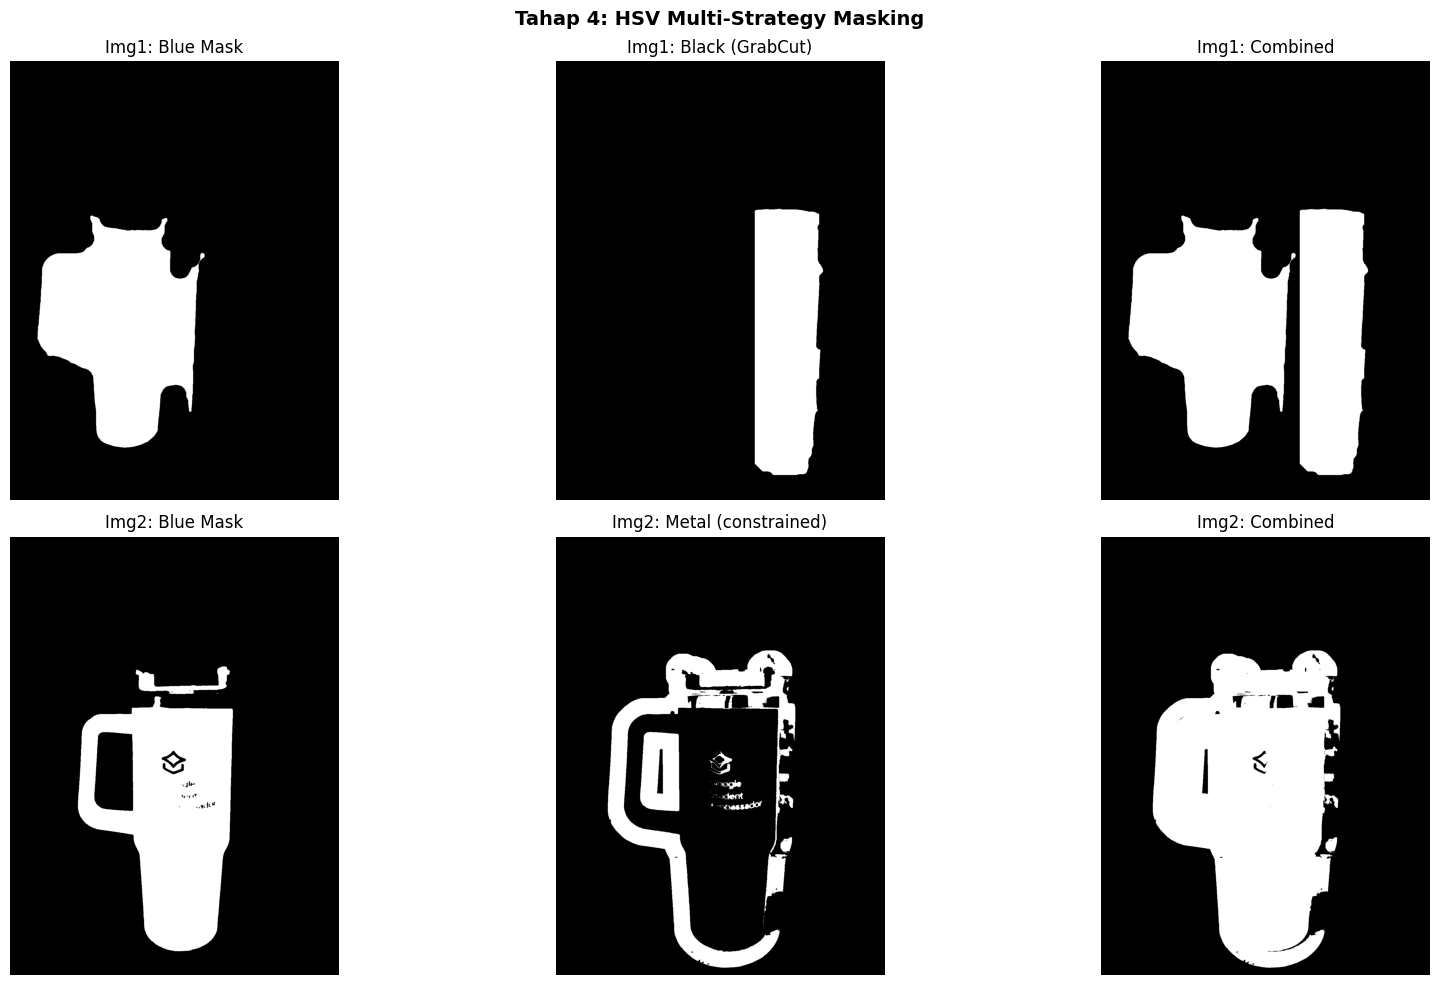

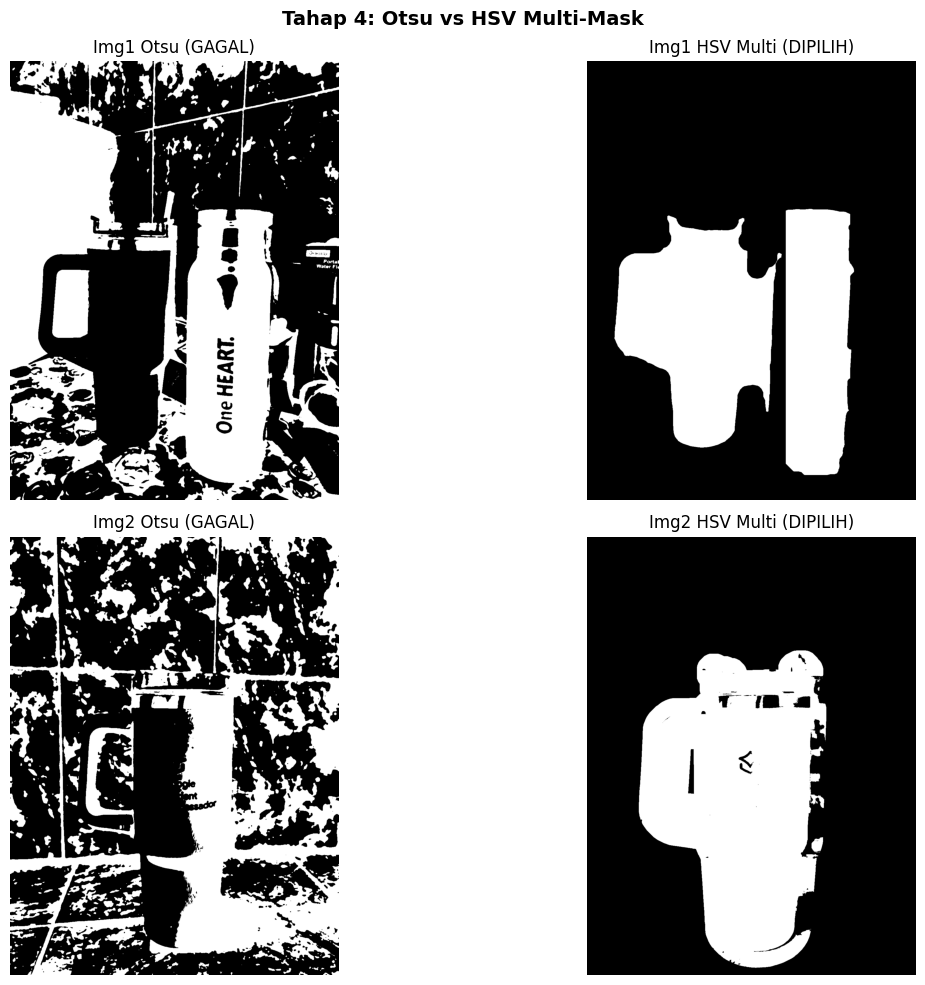

EVALUASI TAHAP 4
  [Image 1] coverage=28.2%  blobs=2  largest=322,644px
  [Image 2] coverage=28.1%  blobs=24  largest=547,827px


In [ ]:
img1_hsv_f = cv2.cvtColor(img1_bgr_f, cv2.COLOR_BGR2HSV)
img2_hsv_f = cv2.cvtColor(img2_bgr_f, cv2.COLOR_BGR2HSV)
h1, w1 = img1_bgr.shape[:2]
h2, w2 = img2_bgr.shape[:2]
ko = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

# ============================================================
# IMAGE 1: Tumbler Biru
# ============================================================
blue1 = cv2.inRange(img1_hsv_f, np.array([85, 20, 20]), np.array([130, 220, 200]))
blue1_m = cv2.morphologyEx(blue1, cv2.MORPH_OPEN, ko, iterations=2)
blue1_m = cv2.morphologyEx(blue1_m, cv2.MORPH_CLOSE,
            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25)), iterations=3)
cnts, _ = cv2.findContours(blue1_m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
blue1_f = np.zeros_like(blue1_m)
blue1_cont = max(cnts, key=cv2.contourArea)
cv2.drawContours(blue1_f, [blue1_cont], -1, 255, -1)
bx, by, bw, bh = cv2.boundingRect(blue1_cont)
print(f"[Img1 Blue] bbox=({bx},{by},{bw},{bh}) area={cv2.contourArea(blue1_cont):.0f}")

# ============================================================
# IMAGE 1: Tumbler Hitam — GrabCut (classical graph-cut)
# ============================================================
# Tentukan ROI rectangle berdasarkan posisi tumbler biru (anchor)
rx = bx + bw + 15       # mulai setelah tumbler biru + gap
ry = max(0, by - 60)     # sertakan tutup
rw = 250                 # lebar estimasi tumbler
rh = bh + 160            # sertakan bagian bawah
if rx + rw > w1: rw = w1 - rx
if ry + rh > h1: rh = h1 - ry
gc_rect = (rx, ry, rw, rh)
print(f"[Img1 Black] GrabCut rect: {gc_rect}")

# Fase 1: GrabCut dengan rectangle initialization
mask_gc = np.zeros(img1_bgr.shape[:2], np.uint8)
bgd_model = np.zeros((1, 65), np.float64)
fgd_model = np.zeros((1, 65), np.float64)
cv2.grabCut(img1_bgr, mask_gc, gc_rect, bgd_model, fgd_model, 10, cv2.GC_INIT_WITH_RECT)

# Fase 2: Tandai area tumbler biru sebagai definite background, lalu refine
mask_gc[blue1_f > 0] = cv2.GC_BGD
cv2.grabCut(img1_bgr, mask_gc, None, bgd_model, fgd_model, 5, cv2.GC_INIT_WITH_MASK)

# Ekstrak foreground
gc_fg = np.where((mask_gc == cv2.GC_FGD) | (mask_gc == cv2.GC_PR_FGD), 255, 0).astype('uint8')
gc_fg = cv2.bitwise_and(gc_fg, cv2.bitwise_not(blue1_f))

# Morfologi ringan + keep largest
gc_clean = cv2.morphologyEx(gc_fg, cv2.MORPH_OPEN, ko, iterations=1)
gc_clean = cv2.morphologyEx(gc_clean, cv2.MORPH_CLOSE,
              cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15)), iterations=2)
cnts_gc, _ = cv2.findContours(gc_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
black1_f = np.zeros(img1_bgr.shape[:2], dtype=np.uint8)
if cnts_gc:
    cv2.drawContours(black1_f, [max(cnts_gc, key=cv2.contourArea)], -1, 255, -1)
print(f"[Img1 Black] GrabCut area={np.sum(black1_f > 0)}")

# Gabungan Image 1
img1_binary = blue1_f | black1_f

# ============================================================
# IMAGE 2: Tumbler Biru + Rim Metalik
# ============================================================
blue2 = cv2.inRange(img2_hsv_f, np.array([85, 25, 70]), np.array([130, 210, 255]))
metal2 = cv2.inRange(img2_hsv_f, np.array([0, 0, 90]), np.array([180, 45, 220]))
roi_k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (60, 60))
blue2_roi = cv2.dilate(blue2, roi_k, iterations=2)
metal2_c = cv2.bitwise_and(metal2, blue2_roi)
img2_binary = cv2.bitwise_or(blue2, metal2_c)

# ============================================================
# VISUALISASI
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0,0].imshow(blue1_f, cmap='gray'); axes[0,0].set_title('Img1: Blue Mask'); axes[0,0].axis('off')
axes[0,1].imshow(black1_f, cmap='gray'); axes[0,1].set_title('Img1: Black (GrabCut)'); axes[0,1].axis('off')
axes[0,2].imshow(img1_binary, cmap='gray'); axes[0,2].set_title('Img1: Combined'); axes[0,2].axis('off')
axes[1,0].imshow(blue2, cmap='gray'); axes[1,0].set_title('Img2: Blue Mask'); axes[1,0].axis('off')
axes[1,1].imshow(metal2_c, cmap='gray'); axes[1,1].set_title('Img2: Metal (constrained)'); axes[1,1].axis('off')
axes[1,2].imshow(img2_binary, cmap='gray'); axes[1,2].set_title('Img2: Combined'); axes[1,2].axis('off')
fig.suptitle('Tahap 4: HSV Multi-Strategy Masking', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Perbandingan Otsu vs HSV
_, img1_otsu = cv2.threshold(img1_clahe, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
_, img2_otsu = cv2.threshold(img2_clahe, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].imshow(img1_otsu, cmap='gray'); axes[0,0].set_title("Img1 Otsu (GAGAL)"); axes[0,0].axis('off')
axes[0,1].imshow(img1_binary, cmap='gray'); axes[0,1].set_title("Img1 HSV Multi (DIPILIH)"); axes[0,1].axis('off')
axes[1,0].imshow(img2_otsu, cmap='gray'); axes[1,0].set_title("Img2 Otsu (GAGAL)"); axes[1,0].axis('off')
axes[1,1].imshow(img2_binary, cmap='gray'); axes[1,1].set_title("Img2 HSV Multi (DIPILIH)"); axes[1,1].axis('off')
fig.suptitle('Tahap 4: Otsu vs HSV Multi-Mask', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

def evaluasi_mask(mask, nama):
    det = int(np.sum(mask > 0))
    cov = det / mask.size * 100
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    lg = max([cv2.contourArea(c) for c in cnts], default=0)
    print(f"  [{nama}] coverage={cov:.1f}%  blobs={len(cnts)}  largest={int(lg):,}px")
print("=" * 60)
print("EVALUASI TAHAP 4")
print("=" * 60)
evaluasi_mask(img1_binary, "Image 1")
evaluasi_mask(img2_binary, "Image 2")
print("=" * 60)

## Analisis Hasil & Insight Tahap 4: Binarisasi — HSV Multi-Strategy Masking

Tahap ini adalah **inti dari pipeline** — mengubah citra menjadi mask biner (objek=putih, background=hitam) menggunakan strategi berbeda untuk setiap tumbler.


### Image 1: Strategi Per-Tumbler

#### Tumbler Biru — HSV Color Masking

| Parameter | Nilai |
|-----------|-------|
| Hue range | 85–130 |
| Saturation range | 20–220 |
| Value range | 20–200 |
| Morphology | Opening (5×5, 2 iter) + Closing (25×25, 3 iter) |
| Selection | Largest contour |

**Hasil (Img1: Blue Mask):**
- Body tumbler, cap/tutup, dan handle **terdeteksi dengan baik** — membentuk satu blob solid.
- Lubang hitam pada body (area straw) dan celah di handle terlihat sebagai hole di mask — ini wajar karena area tersebut bukan berwarna biru.
- Tidak ada false positive dari background — Hue biru (≈100–120) benar-benar unik di scene ini.

#### Tumbler Hitam — GrabCut (Anchor-Based)

| Parameter | Nilai |
|-----------|-------|
| Metode | GrabCut (Rother et al., 2004) — graph-cut klasik |
| ROI Anchor | Bounding box tumbler biru + offset 15px ke kanan |
| Rectangle | `(rx, ry, 250, bh+160)` — mencakup cap hingga dasar |
| Iterasi | Fase 1: 10 iterasi (rect init), Fase 2: 5 iterasi (mask refinement) |
| Refinement | Area tumbler biru ditandai sebagai *definite background* |

**Hasil (Img1: Black GrabCut):**
- GrabCut berhasil mengisolasi **body silindris tumbler hitam** mengikuti kontur sebenarnya — bukan kotak persegi panjang.
- Bagian cap/tutup metalik ikut terdeteksi sebagai foreground.
- Background noisy (lemari, kotak kardus, kain bunga) **berhasil dieliminasi** berkat mekanisme graph-cut yang memodelkan distribusi warna foreground vs background secara statistik.

#### Combined Mask (Img1)

Gabungan `blue_mask | black_mask` menghasilkan mask dengan **dua blob terpisah** — prerequisite utama untuk instance segmentation di tahap selanjutnya.


### Image 2: HSV + Metallic Rim Constraint

| Komponen | HSV Range |
|----------|-----------|
| Body biru | H=85–130, S=25–210, V=70–255 |
| Rim metalik | H=0–180, S=0–45, V=90–220 |
| Constraint | Metal mask di-*AND*-kan dengan dilasi blue mask (60×60) agar hanya rim di sekitar tumbler yang masuk |

**Hasil (Img2):**
- **Blue Mask:** Body tumbler terdeteksi solid. Logo dan teks putih terlihat sebagai hole kecil (saturasi rendah, tidak masuk range biru).
- **Metal (constrained):** Rim metalik di bagian atas dan handle berhasil ditangkap tanpa mendeteksi area keramik background yang juga rendah saturasi — berkat constraint dilasi.
- **Combined:** Mask menyeluruh mencakup body + rim + handle.


### Analisis Hasil & Insight Tahap 4

#### Perbandingan Otsu vs HSV Multi-Strategy

| Kriteria | Otsu Thresholding | HSV Multi-Strategy |
|----------|-------------------|--------------------|
| **Img1 — Objek** | Tumbler biru terdeteksi terbalik (sebagai background), tumbler hitam menyatu dengan bayangan | Kedua tumbler terisolasi sebagai blob terpisah |
| **Img1 — Background** | Kain bunga, lemari, kotak kardus ikut terdeteksi sebagai foreground | Background bersih, hanya objek target |
| **Img2 — Objek** | Body tumbler terdeteksi tapi fragmentasi berat, banyak hole | Body solid dengan detail rim |
| **Img2 — Background** | Tekstur keramik menciptakan noise besar-besaran | Background bersih |
| **Verdict** | GAGAL — thresholding global tidak bisa menangani scene multi-objek multi-warna | DIPILIH — deteksi berbasis warna + spatial anchor |

**Mengapa Otsu gagal?** Otsu mengasumsikan distribusi intensitas bimodal (objek vs background). Pada Image 1 dengan 2 tumbler berbeda warna + background heterogen, distribusi intensitasnya **multimodal** — satu threshold global tidak mungkin memisahkan semua objek sekaligus.

---

## Tahap 5: Operasi Morfologi
- **Opening** (Erode→Dilate): menghapus noise kecil
- **Closing** (Dilate→Erode): menutup lubang di dalam area tumbler
- **Largest N contour filter**: memastikan hanya N objek terbesar yang lolos

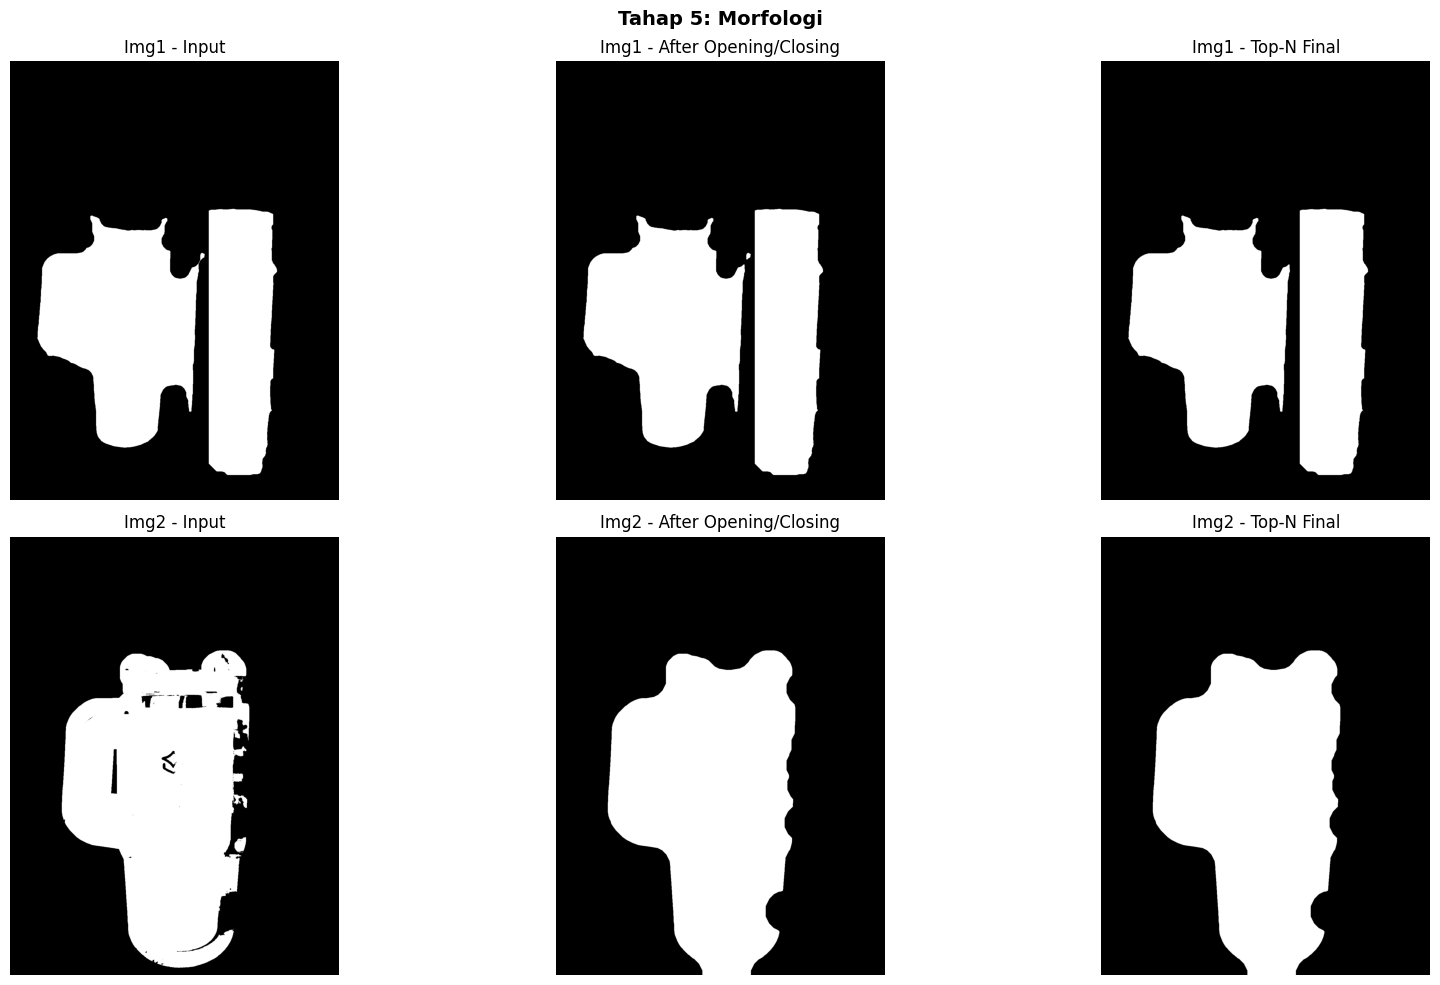

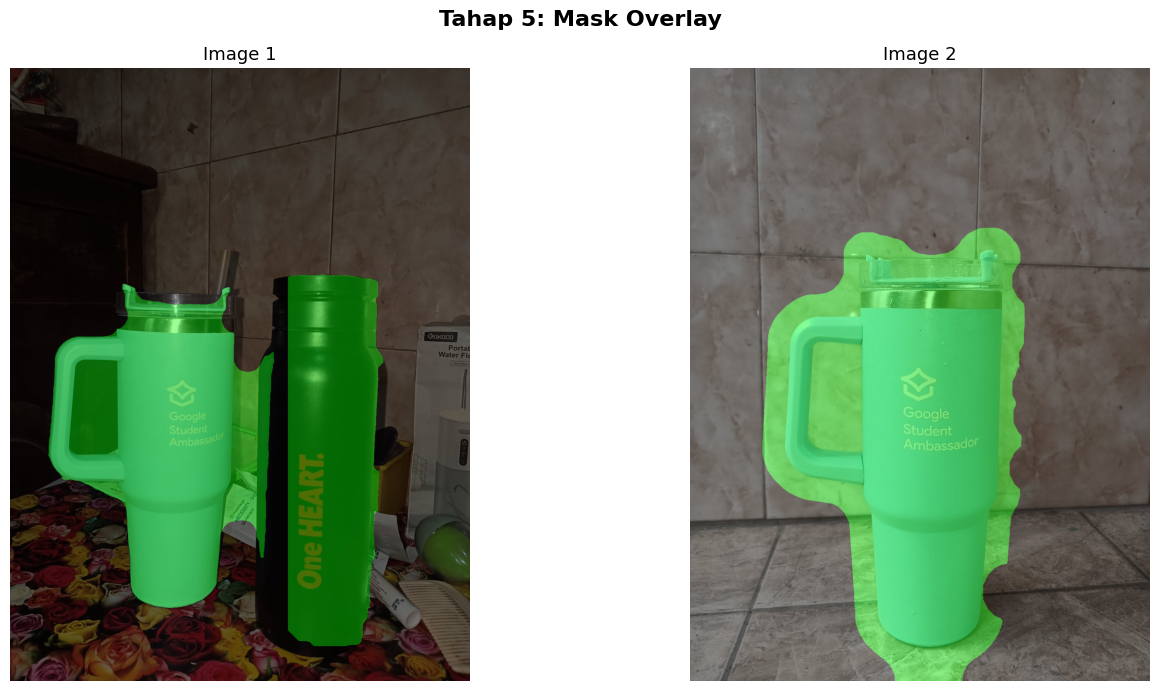

In [ ]:
k_open = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))

def morph_keep_top_n(mask, n, ko, kc, oi=2, ci=4):
    opened = cv2.morphologyEx(mask, cv2.MORPH_OPEN, ko, iterations=oi)
    closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kc, iterations=ci)
    cnts, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:n]
    clean = np.zeros_like(closed)
    for c in cnts:
        cv2.drawContours(clean, [c], -1, 255, -1)
    return opened, closed, clean

# Image 1: masks sudah di-morph per-tumbler di Tahap 4
# Hanya opening ringan + keep top 2 (TANPA closing besar agar tidak merge)
img1_op = cv2.morphologyEx(img1_binary, cv2.MORPH_OPEN, k_open, iterations=1)
cnts1, _ = cv2.findContours(img1_op, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts1 = sorted(cnts1, key=cv2.contourArea, reverse=True)[:2]
img1_morph = np.zeros_like(img1_op)
for c in cnts1:
    cv2.drawContours(img1_morph, [c], -1, 255, -1)

# Image 2: perlu full opening + closing
img2_op, img2_cl, img2_morph = morph_keep_top_n(img2_binary, 1, k_open, k_close)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for j, (t1, t2, nm) in enumerate([(img1_binary, img2_binary, 'Input'),
                                    (img1_op, img2_cl, 'After Opening/Closing'),
                                    (img1_morph, img2_morph, 'Top-N Final')]):
    axes[0,j].imshow(t1, cmap='gray'); axes[0,j].set_title(f'Img1 - {nm}'); axes[0,j].axis('off')
    axes[1,j].imshow(t2, cmap='gray'); axes[1,j].set_title(f'Img2 - {nm}'); axes[1,j].axis('off')
fig.suptitle('Tahap 5: Morfologi', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

def overlay_mask(img_rgb, mask, color=(0,255,0), alpha=0.4):
    out = img_rgb.copy().astype(np.float32)
    ov = np.zeros_like(out); ov[mask > 0] = color
    return np.clip(out*(1-alpha) + ov*alpha, 0, 255).astype(np.uint8)

tampilkan_komparasi(overlay_mask(img1_rgb, img1_morph),
                    overlay_mask(img2_rgb, img2_morph),
                    title='Tahap 5: Mask Overlay')

## Analisis Hasil & Insight Tahap 5: Operasi Morfologi

### Parameter

| Operasi | Kernel | Image 1 | Image 2 |
|---------|--------|---------|---------|
| Opening | Ellipse 5×5 | 1 iterasi (ringan, mask sudah pre-morphed) | 2 iterasi |
| Closing | Ellipse 35×35 |  **Tidak diterapkan** — agar 2 blob tidak merge | 4 iterasi |
| Top-N Filter | — | Keep top 2 contour | Keep top 1 contour |

> **Catatan penting:** Image 1 menggunakan strategi morfologi berbeda dari Image 2. Karena mask biru dan hitam sudah di-morph secara independen di Tahap 4, menerapkan closing besar pada gabungannya akan menyebabkan kedua blob **menyatu menjadi satu** — menghancurkan instance separation.




### Hasil Observasi

#### Image 1 (Input → Opening → Top-2 Final)

| Tahap | Perubahan |
|-------|-----------|
| **Input** | Gabungan mask dari Tahap 4 — dua blob (biru + hitam) sudah terpisah, namun terdapat beberapa fragmen kecil dan tepi yang bergerigi |
| **After Opening** | Fragmen-fragmen kecil di tepi mask tereliminasi, kontur menjadi lebih bersih. Kedua blob **tetap terpisah** |
| **Top-2 Final** | Hanya 2 contour terbesar yang dipertahankan — memastikan tidak ada blob sisa dari noise yang lolos |

#### Image 2 (Input → Closing → Top-1 Final)

| Tahap | Perubahan |
|-------|-----------|
| **Input** | Mask dari HSV + metal constraint — body utama solid tapi ada hole di area logo dan fragmen scattered di tepi |
| **After Closing** | Hole-hole di dalam body tertutup, fragmen yang berdekatan menyatu. Mask menjadi **satu blob kompak** yang meng-cover seluruh tumbler |
| **Top-1 Final** | Blob terbesar diambil — mengeliminasi noise kecil yang mungkin tersisa di pinggir |

#### Mask Overlay

- **Image 1:** Overlay hijau menunjukkan kedua tumbler ter-cover dengan baik — tumbler biru (body + handle + cap) dan tumbler hitam (body silindris) masing-masing memiliki mask tersendiri tanpa saling tumpang-tindih.
- **Image 2:** Tumbler biru di-cover secara menyeluruh termasuk handle dan cap. Sedikit bleeding di tepi mask (area keramik yang ikut tercakup) — ini akan di-refine oleh Watershed di tahap selanjutnya.

### Peran dalam Pipeline

Morfologi berfungsi sebagai tahap **pembersihan** sebelum Distance Transform dan Watershed. Tanpa tahap ini, fragmen-fragmen kecil akan menghasilkan marker palsu di Watershed yang menyebabkan over-segmentation.

---

## Tahap 6: Distance Transform
Distance Transform menghitung jarak setiap piksel foreground ke edge terdekat. Piksel dengan nilai tertinggi = **pusat objek** (*sure foreground*).

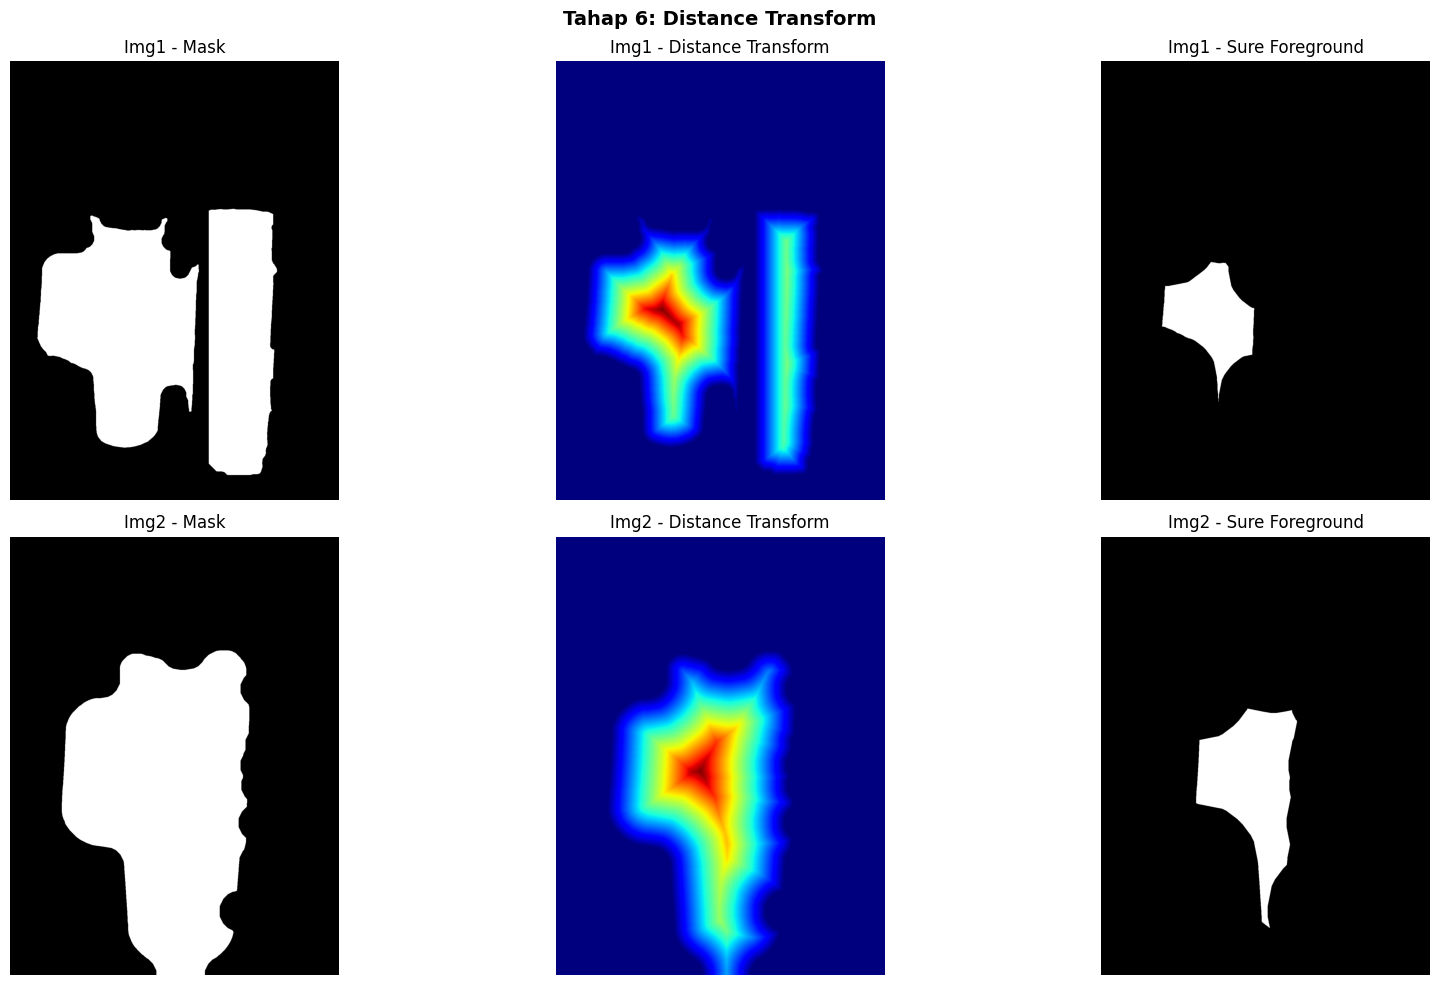

In [ ]:
img1_dist = cv2.distanceTransform(img1_morph, cv2.DIST_L2, 5)
img2_dist = cv2.distanceTransform(img2_morph, cv2.DIST_L2, 5)
img1_dn = cv2.normalize(img1_dist, None, 0, 1.0, cv2.NORM_MINMAX)
img2_dn = cv2.normalize(img2_dist, None, 0, 1.0, cv2.NORM_MINMAX)

_, img1_sfg = cv2.threshold(img1_dist, 0.5 * img1_dist.max(), 255, 0)
_, img2_sfg = cv2.threshold(img2_dist, 0.5 * img2_dist.max(), 255, 0)
img1_sfg = np.uint8(img1_sfg)
img2_sfg = np.uint8(img2_sfg)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for j, (t1, t2, nm) in enumerate([(img1_morph, img2_morph, 'Mask'),
                                    (img1_dn, img2_dn, 'Distance Transform'),
                                    (img1_sfg, img2_sfg, 'Sure Foreground')]):
    cm = 'jet' if j == 1 else 'gray'
    axes[0,j].imshow(t1, cmap=cm); axes[0,j].set_title(f'Img1 - {nm}'); axes[0,j].axis('off')
    axes[1,j].imshow(t2, cmap=cm); axes[1,j].set_title(f'Img2 - {nm}'); axes[1,j].axis('off')
fig.suptitle('Tahap 6: Distance Transform', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Analisis hasil & Insighy Tahap 6: Distance Transform

Parameter: `cv2.distanceTransform(mask, cv2.DIST_L2, maskSize=5)` — menggunakan jarak Euclidean (L2).

Sure foreground threshold: `0.5 × max_distance` — piksel dengan jarak > 50% dari nilai maksimum dianggap sebagai **pusat objek** yang pasti foreground.




### Hasil Observasi

#### Distance Transform (Heat Map)

| Aspek | Image 1 | Image 2 |
|-------|---------|---------|
| Tumbler biru | Pusat panas (merah/kuning) berada di **tengah body** — area terlebar dari tumbler. Handle dan cap memiliki nilai rendah (biru) karena dekat tepi | Satu pusat panas besar di tengah body |
| Tumbler hitam | Pusat panas berada di **tengah body silindris** — bentuknya memanjang vertikal sesuai geometri tumbler | — |
| Separasi | Dua pusat panas yang **jelas terpisah** — konfirmasi bahwa kedua blob tidak menyatu | Satu pusat panas tunggal |

Heat map membaca mask sebagai "topografi" — semakin jauh piksel dari tepi foreground, semakin tinggi nilainya (merah). Ini secara natural mengidentifikasi **pusat massa** setiap objek.

#### Sure Foreground

| Aspek | Image 1 | Image 2 |
|-------|---------|---------|
| Hasil | **Dua region terpisah** — satu untuk tumbler biru (kiri), satu untuk tumbler hitam (kanan) | Satu region kompak di tengah body |
| Coverage | Hanya bagian inti (center body) yang lolos threshold — handle, cap, dan tepi ter-exclude | Bagian inti body tanpa handle dan cap |
| Fungsi | Menjadi **seed marker** untuk Watershed — memastikan 2 objek dimulai dari titik yang berbeda | Seed tunggal untuk 1 objek |

### Peran dalam Pipeline

Distance Transform menghasilkan **sure foreground** yang dijamin berada di interior objek. Area antara sure foreground dan tepi mask (sure background) menjadi **unknown region** — zona inilah yang akan diputuskan oleh Watershed di tahap berikutnya, apakah termasuk objek atau background.

---

## Tahap 7: Watershed Segmentation
Watershed memperlakukan citra sebagai *topographic surface*. Markers dari Distance Transform digunakan sebagai seed. Boundary ditandai `-1`.

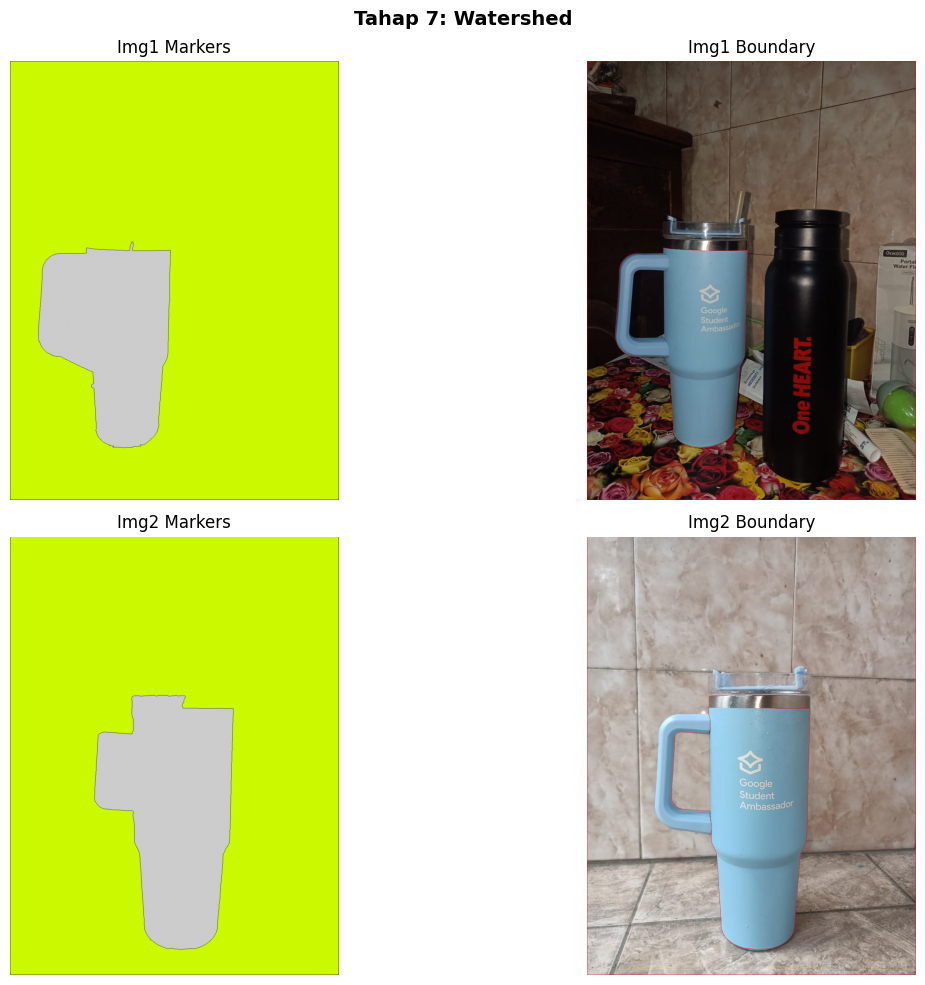

Watershed regions: Img1=1, Img2=1


In [ ]:
def apply_watershed(img_bgr, morph_mask, sure_fg):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    sure_bg = cv2.dilate(morph_mask, k, iterations=3)
    unknown = cv2.subtract(sure_bg, sure_fg)
    n, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    img_ws = img_bgr.copy()
    markers_ws = cv2.watershed(img_ws, markers)
    return markers, markers_ws, n - 1

img1_mk, img1_ws, img1_cnt = apply_watershed(img1_bgr, img1_morph, img1_sfg)
img2_mk, img2_ws, img2_cnt = apply_watershed(img2_bgr, img2_morph, img2_sfg)

img1_ov = img1_rgb.copy(); img1_ov[img1_ws == -1] = [255, 0, 0]
img2_ov = img2_rgb.copy(); img2_ov[img2_ws == -1] = [255, 0, 0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].imshow(img1_ws, cmap='nipy_spectral'); axes[0,0].set_title('Img1 Markers'); axes[0,0].axis('off')
axes[0,1].imshow(img1_ov); axes[0,1].set_title('Img1 Boundary'); axes[0,1].axis('off')
axes[1,0].imshow(img2_ws, cmap='nipy_spectral'); axes[1,0].set_title('Img2 Markers'); axes[1,0].axis('off')
axes[1,1].imshow(img2_ov); axes[1,1].set_title('Img2 Boundary'); axes[1,1].axis('off')
fig.suptitle('Tahap 7: Watershed', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"Watershed regions: Img1={img1_cnt}, Img2={img2_cnt}")

## Analisis Hasil & Insight Tahap 7: Watershed Segmentation

### Cara Kerja

Watershed memperlakukan citra sebagai *topographic surface* di mana intensitas piksel = ketinggian. Input terdiri dari 3 zona marker:

| Label | Sumber | Keterangan |
|-------|--------|------------|
| `sure_fg` (≥2) | Distance Transform > 50% max | Pusat objek — pasti foreground |
| `sure_bg` (=1) | Dilasi mask + 3 iterasi | Area luar — pasti background |
| `unknown` (=0) | `sure_bg − sure_fg` | Zona abu-abu yang diputuskan Watershed |

Boundary antar region ditandai nilai **-1** (merah pada Boundary output).




### Hasil observasi

#### Marker Map

- **Image 1:** Tampak **dua region abu-abu** terpisah (tumbler biru kiri, tumbler hitam kanan) di atas background kuning-hijau (sure background). Separasi antar dua marker sangat jelas — tidak ada overlap. Ini mengkonfirmasi bahwa pipeline berhasil menjaga 2 instance tetap distinct sejak awal.
- **Image 2:** Satu region abu-abu tunggal di tengah citra yang merepresentasikan 1 tumbler, background kuning-hijau mengelilinginya.

#### Boundary Overlay

| Aspek | Image 1 | Image 2 |
|-------|---------|---------|
| Boundary tumbler biru | Garis merah tipis mengikuti tepi body + handle + cap | — |
| Boundary tumbler hitam | Garis merah mengikuti kontur silindris body | — |
| Boundary tumbler (Img2) | — | Garis merah rapi mengikuti tepi body, handle, dan bagian bawah |
| Separasi antar objek | Boundary antar tumbler biru-hitam **terdeteksi** meski jaraknya dekat | N/A |

**Catatan Image 2:** Garis boundary sudah sangat rapi mengikuti kontur fisik tumbler — cap metalik, handle kotak, dan transisi body ke base terdefinisi dengan baik.

### Catatan Limitasi

- **Image 1:** Watershed bekerja dari **single combined mask** — sehingga boundary yang dihasilkan bersifat global, bukan per-instance. Pemisahan instance tetap bergantung pada dua blob terpisah dari Tahap 5.
- Jika dua marker terlalu dekat atau overlap, Watershed bisa menggabungkan keduanya — inilah alasan kenapa menjaga separasi mask di Tahap 4–5 sangat kritis.


---

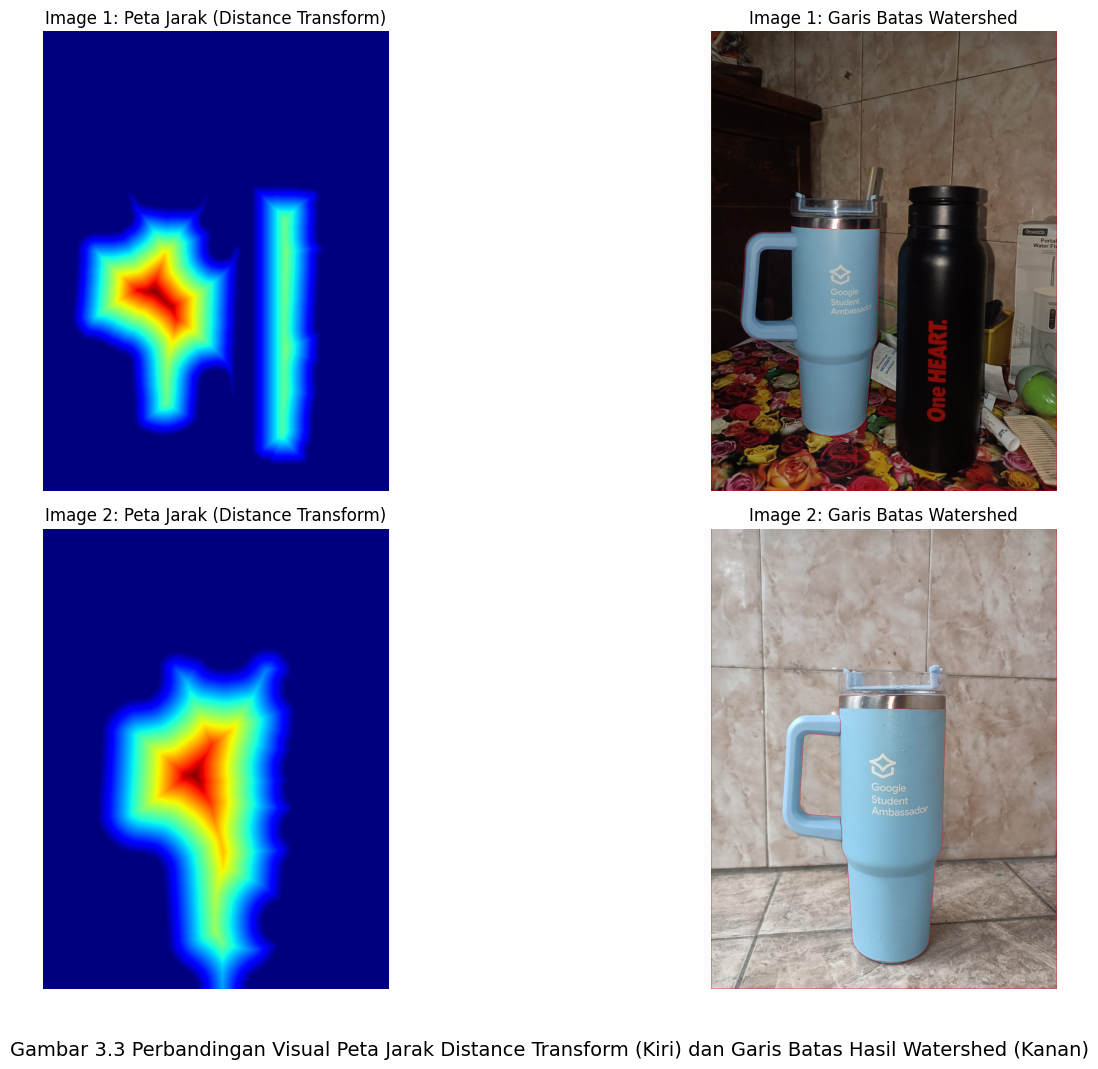

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Image 1: Distance Transform vs Watershed Boundary
axes[0,0].imshow(img1_dn, cmap='jet')
axes[0,0].set_title('Image 1: Peta Jarak (Distance Transform)')
axes[0,0].axis('off')

axes[0,1].imshow(img1_ov)
axes[0,1].set_title('Image 1: Garis Batas Watershed')
axes[0,1].axis('off')

# Image 2: Distance Transform vs Watershed Boundary
axes[1,0].imshow(img2_dn, cmap='jet')
axes[1,0].set_title('Image 2: Peta Jarak (Distance Transform)')
axes[1,0].axis('off')

axes[1,1].imshow(img2_ov)
axes[1,1].set_title('Image 2: Garis Batas Watershed')
axes[1,1].axis('off')

fig.suptitle('Gambar 3.3 Perbandingan Visual Peta Jarak Distance Transform (Kiri) dan Garis Batas Hasil Watershed (Kanan)', fontsize=14, y=0.05)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

## Tahap 8: Ekstraksi Kontur & Evaluasi Akhir

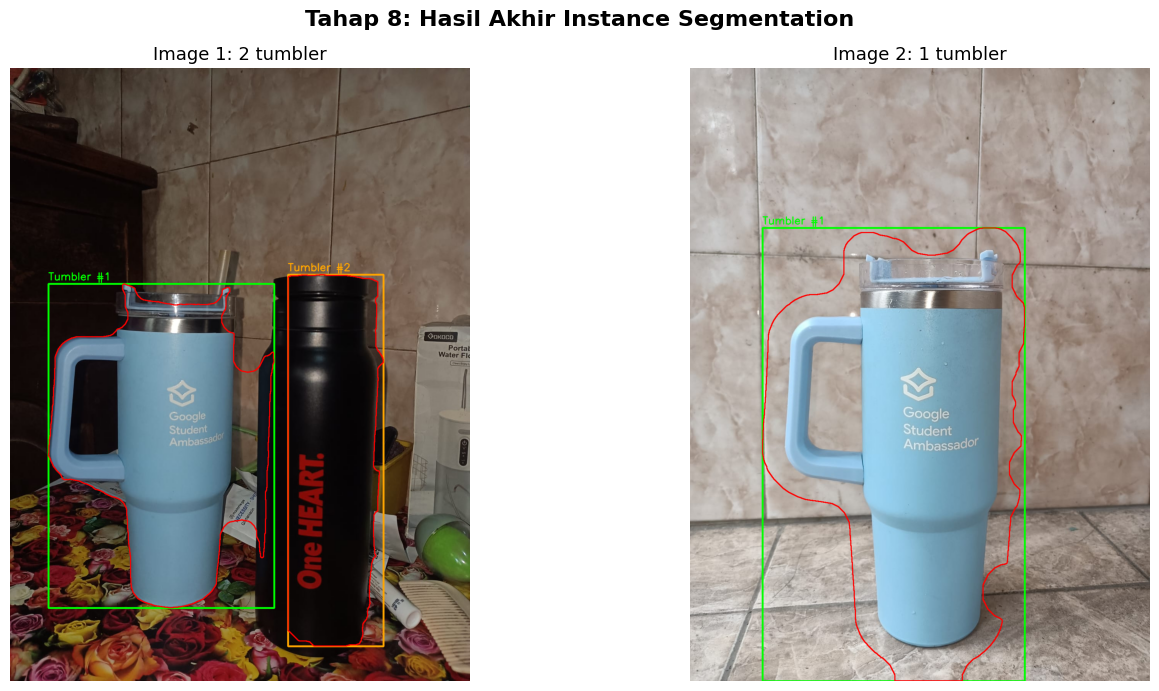

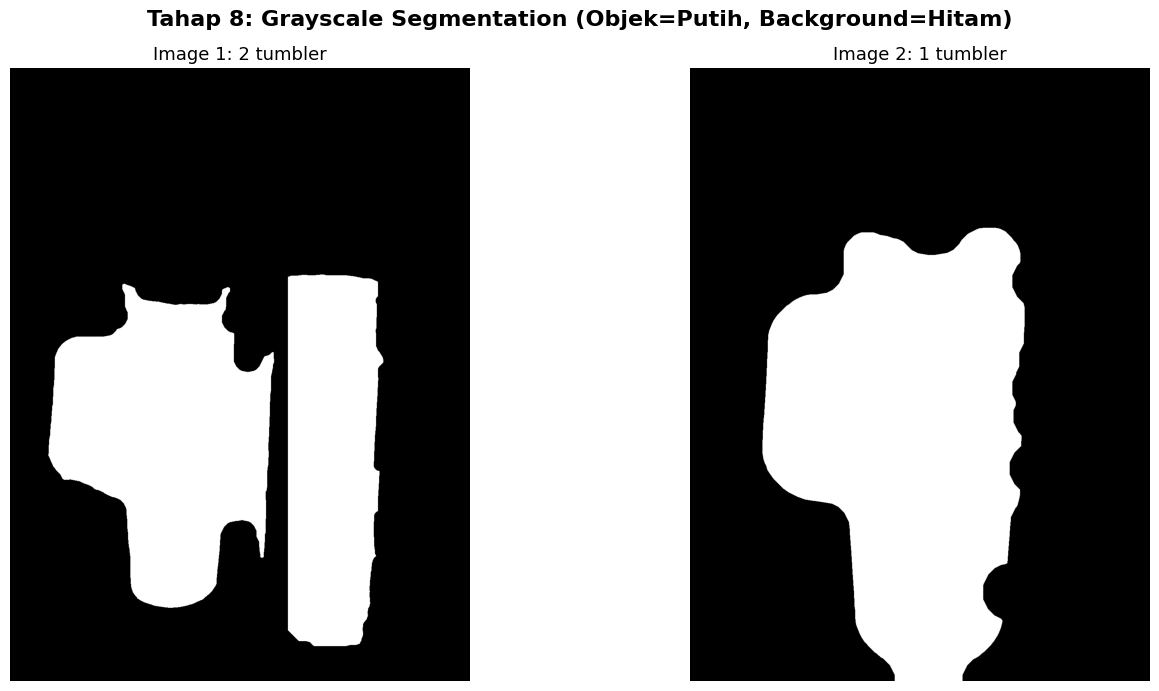

EVALUASI PIPELINE FINAL
  Image 1 | Deteksi: 2 | GT: 2 | BERHASIL
  Image 2 | Deteksi: 1 | GT: 1 | BERHASIL


In [ ]:
def extract_and_draw(img_rgb, mask, min_frac=0.01):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    h, w = mask.shape
    valid = [c for c in cnts if cv2.contourArea(c) > min_frac * h * w]
    valid = sorted(valid, key=cv2.contourArea, reverse=True)
    out = img_rgb.copy()
    colors = [(0,255,0), (255,165,0), (0,255,255)]
    for i, c in enumerate(valid):
        col = colors[i % len(colors)]
        x, y, bw, bh = cv2.boundingRect(c)
        cv2.rectangle(out, (x, y), (x+bw, y+bh), col, 3)
        cv2.drawContours(out, [c], -1, (255, 0, 0), 2)
        cv2.putText(out, f'Tumbler #{i+1}', (x, max(y-10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, col, 2)
    return out, len(valid)

img1_res, img1_n = extract_and_draw(img1_rgb, img1_morph)
img2_res, img2_n = extract_and_draw(img2_rgb, img2_morph)

tampilkan_komparasi(img1_res, img2_res,
    judul1=f'Image 1: {img1_n} tumbler', judul2=f'Image 2: {img2_n} tumbler',
    title='Tahap 8: Hasil Akhir Instance Segmentation')

# Grayscale output: objek putih, background hitam
img1_gs = np.zeros(img1_bgr.shape[:2], dtype=np.uint8)
img1_gs[img1_morph > 0] = 255
img2_gs = np.zeros(img2_bgr.shape[:2], dtype=np.uint8)
img2_gs[img2_morph > 0] = 255
tampilkan_komparasi(img1_gs, img2_gs, cmap1='gray', cmap2='gray',
    judul1=f'Image 1: {img1_n} tumbler', judul2=f'Image 2: {img2_n} tumbler',
    title='Tahap 8: Grayscale Segmentation (Objek=Putih, Background=Hitam)')

gt1, gt2 = 2, 1
print("=" * 55)
print("EVALUASI PIPELINE FINAL")
print("=" * 55)
for nm, n, gt in [('Image 1', img1_n, gt1), ('Image 2', img2_n, gt2)]:
    s = 'BERHASIL' if n == gt else 'GAGAL'
    print(f"  {nm} | Deteksi: {n} | GT: {gt} | {s}")
print("=" * 55)

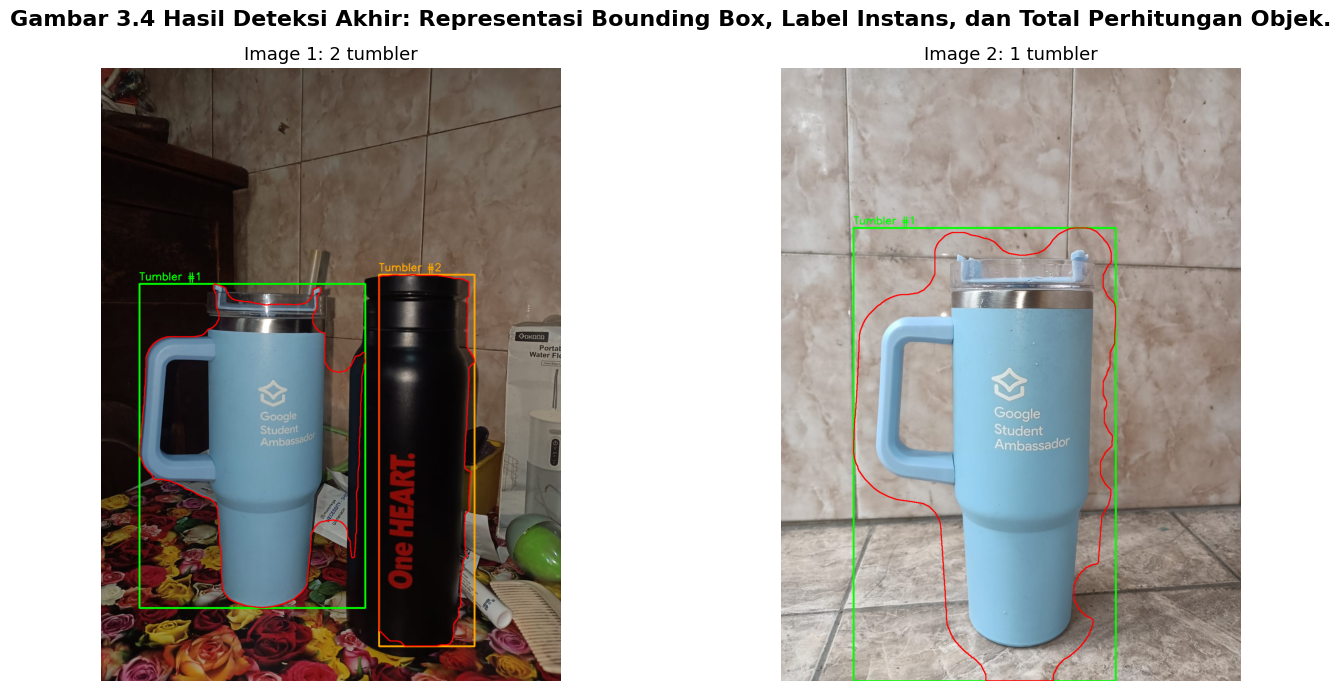

In [ ]:
tampilkan_komparasi(img1_res, img2_res, judul1=f'Image 1: {img1_n} tumbler', judul2=f'Image 2: {img2_n} tumbler', title='Gambar 3.4 Hasil Deteksi Akhir: Representasi Bounding Box, Label Instans, dan Total Perhitungan Objek.')

## Analisis Hasil & Insight Tahap 8: Ekstraksi Kontur & Evaluasi Akhir

Kontur diekstraksi menggunakan `cv2.findContours` dengan mode `RETR_EXTERNAL` — hanya kontur terluar yang diambil. Filter minimum area `0.01 × (H × W)` diterapkan untuk membuang fragmen kecil sisa.


### Hasil Observasi

#### Instance Segmentation Output

**Image 1 — 2 Tumbler:**

| Objek | Bounding Box | Kontur (Merah) | Keterangan |
|-------|-------------|----------------|------------|
| Tumbler #1 (Biru) | Hijau — melingkupi body + handle | Mengikuti bentuk tumbler secara umum | Area handle terdeteksi, meski ada sedikit gap di bagian atas cap |
| Tumbler #2 (Hitam) | Oranye — melingkupi body silindris | Kontur mengikuti tepi silinder | Cap/tutup metalik belum sepenuhnya tercakup |

- Dua instance **berhasil dipisahkan** dengan label dan warna bounding box yang berbeda
- Terdapat celah/gap kecil di antara kedua tumbler yang tidak tercakup mask — ini merupakan area straw (sedotan) yang berada di antara keduanya, bukan false negative.

**Image 2 — 1 Tumbler:**

- Satu instance terdeteksi dengan bounding box hijau yang mencakup hampir seluruh tumbler.
- Kontur merah terlihat **bleeding ke kiri** — menangkap sedikit area keramik dan bayangan di samping tumbler, terutama di bagian bawah. Ini terjadi karena mask dari metallic rim constraint sedikit melebar ke background.
- Body, handle, dan bagian bawah tumbler tercakup dengan baik.


#### Grayscale Segmentation (Objek=Putih, Background=Hitam)

**Image 1:**
- Dua blob putih terpisah dengan gap hitam di antara keduanya — membuktikan instance separation berhasil.
- Tumbler biru (kiri): bentuk irregular mengikuti kontur body + handle + cekungan handle.
- Tumbler hitam (kanan): bentuk silindris memanjang vertikal — mencerminkan bentuk body yang lebih ramping.

**Image 2:**
- Satu blob putih besar — body tumbler dengan handle dan base terdefinisi.
- Tepi kanan mask terlihat bergerigi (jagged) — efek dari metallic rim constraint yang menangkap refleksi material di tepi handle.

#### Evaluasi Pipeline Final

| Metrik | Image 1 | Image 2 |
|--------|---------|---------|
| Ground Truth (jumlah tumbler) | 2 | 1 |
| Hasil Deteksi | **2** | **1** |
| Instance Separation | Berhasil — 2 kontur independen | 1 kontur |
| Akurasi Kontur | Baik — mengikuti bentuk umum tumbler | Cukup baik — sedikit bleeding di tepi |
| False Positive | Tidak ada | Minimal (area keramik di tepi kiri) |
| False Negative | Cap tumbler hitam kurang penuh | Straw/sedotan tidak tertangkap |
| **Status** | **BERHASIL** | **BERHASIL** |

## Kesimpulan

| Tahap | Metode | Fungsi |
|-------|--------|--------|
| Spatial Filter | Bilateral Filter | Edge-preserving noise reduction |
| Contrast | CLAHE | Perbaikan kontras lokal |
| Binarisasi | HSV Color Masking + GrabCut | Blue: direct HSV, Black: GrabCut (graph-cut klasik) |
| Morfologi | Opening + Closing + Top-N filter | Noise removal + gap filling |
| Segmentasi | Watershed | Instance separation |

**Inovasi kunci**: Tumbler hitam (achromatic) tidak bisa dideteksi via HSV langsung karena intensitas pikselnya (V<100) tumpang-tindih dengan lemari, bayangan, dan ubin. Solusi: gunakan posisi tumbler biru sebagai *spatial anchor* untuk menentukan ROI, lalu **GrabCut** (algoritma graph-cut dari Rother et al., 2004) untuk memisahkan foreground secara presisi mengikuti kontur objek — sepenuhnya metode klasik tanpa deep learning.